In [11]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\Owner\Downloads\pythondev2\dog_cat_photos\train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\Owner\Downloads\pythondev2\dog_cat_photos\test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [18]:

# 分類名（cat0／dog1）をリストとして確認する
class_names = train_dataset.class_names
class_names



['cat', 'dog']

In [19]:
# データの詳細を表示する
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels)


(32, 224, 224, 3)
tf.Tensor(
[[1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]], shape=(32, 1), dtype=float32)


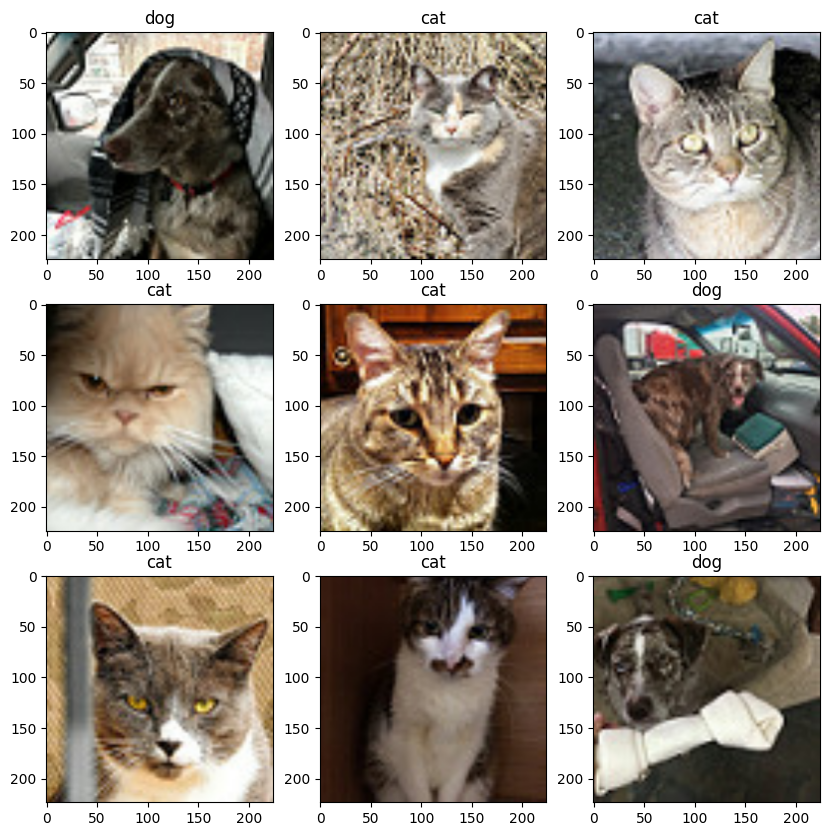

In [20]:
# trainデータの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [21]:
# MobileNetV2モデルを作成（入力層）する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [22]:
# Dense層（出力層）を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [25]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [27]:
# modelをcompileする
model.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=["accuracy"])

In [28]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.7500 - loss: 0.5353
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.9567 - loss: 0.2404
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.9700 - loss: 0.1418
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.9833 - loss: 0.1043
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.9833 - loss: 0.0816
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.9900 - loss: 0.0695
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.9900 - loss: 0.0595
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.9900 - loss: 0.0524
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9933 - loss: 0.0479
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9967 - loss: 0.0421
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.9967 - loss: 0.0385
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step

In [29]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 365ms/step


In [30]:
# 分類した結果を確認する
pred_data

array([[3.44123895e-04],
       [1.15764681e-02],
       [1.30337721e-03],
       [1.65239407e-03],
       [8.94363329e-04],
       [3.59900296e-04],
       [7.70336483e-04],
       [9.33831907e-04],
       [6.79016637e-04],
       [5.58405358e-04],
       [1.92455086e-03],
       [4.00463538e-03],
       [1.37963973e-03],
       [3.53783555e-03],
       [4.26655170e-04],
       [2.58891057e-04],
       [3.72316921e-04],
       [5.92782802e-04],
       [7.41710479e-04],
       [1.69853009e-02],
       [8.76419395e-02],
       [2.77528435e-01],
       [6.27841381e-03],
       [1.65907247e-03],
       [4.43192840e-01],
       [7.70971226e-03],
       [9.32147168e-03],
       [3.71424761e-03],
       [3.18399034e-02],
       [1.16011954e-03],
       [4.00659628e-03],
       [3.94405305e-01],
       [9.08626884e-04],
       [7.44193909e-04],
       [1.25020267e-02],
       [9.26298976e-01],
       [3.10309958e-02],
       [2.00145077e-02],
       [7.60910986e-03],
       [6.22105924e-03],


In [31]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.9900 - loss: 0.0536


[0.05361054465174675, 0.9900000095367432]